In [1]:


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers
from sklearn.metrics import confusion_matrix, classification_report

print("Version de TensorFlow :", tf.__version__)

Version de TensorFlow : 2.20.0


In [2]:


(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Forme de x_train :", x_train.shape)
print("Forme de y_train :", y_train.shape)
print("Forme de x_test :", x_test.shape)
print("Forme de y_test :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forme de x_train : (60000, 28, 28)
Forme de y_train : (60000,)
Forme de x_test : (10000, 28, 28)
Forme de y_test : (10000,)


In [3]:


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Valeur minimale dans x_train :", x_train.min())
print("Valeur maximale dans x_train :", x_train.max())

Valeur minimale dans x_train : 0.0
Valeur maximale dans x_train : 1.0


In [4]:


y_train_one_hot = to_categorical(y_train, num_classes=10)
y_test_one_hot = to_categorical(y_test, num_classes=10)

print("Avant one-hot :", y_train[0])
print("Après one-hot :", y_train_one_hot[0])

Avant one-hot : 5
Après one-hot : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


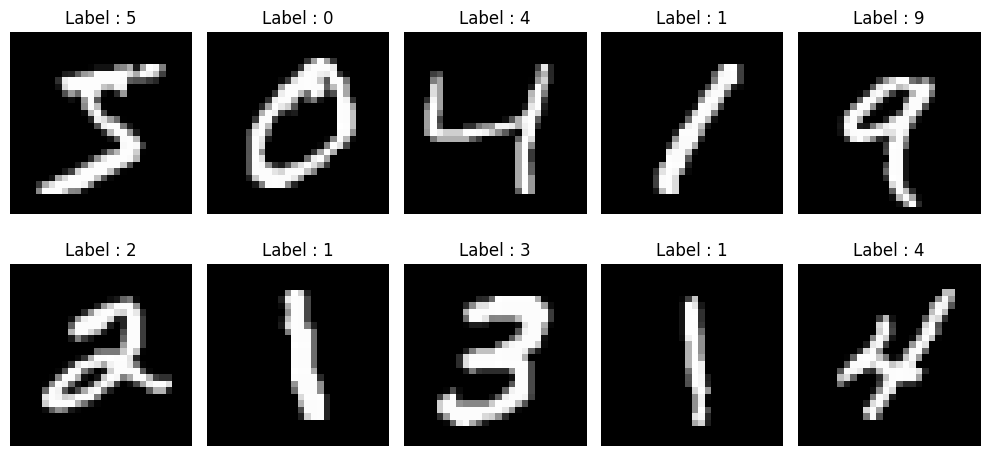

In [5]:


plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label : {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:


model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),

    layers.Dense(128, activation="relu"),

    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:


model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:

history = model.fit(
    x_train,
    y_train_one_hot,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9219 - loss: 0.2694 - val_accuracy: 0.9591 - val_loss: 0.1455
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9645 - loss: 0.1175 - val_accuracy: 0.9682 - val_loss: 0.1071
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9748 - loss: 0.0800 - val_accuracy: 0.9703 - val_loss: 0.0991
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9812 - loss: 0.0597 - val_accuracy: 0.9723 - val_loss: 0.0969
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9846 - loss: 0.0469 - val_accuracy: 0.9726 - val_loss: 0.0986
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9876 - loss: 0.0378 - val_accuracy: 0.9732 - val_loss: 0.0987
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9901 - loss: 0.0307 - val_accuracy: 0.9734 - val_loss: 0.1021
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9916 - loss: 0.0258 -

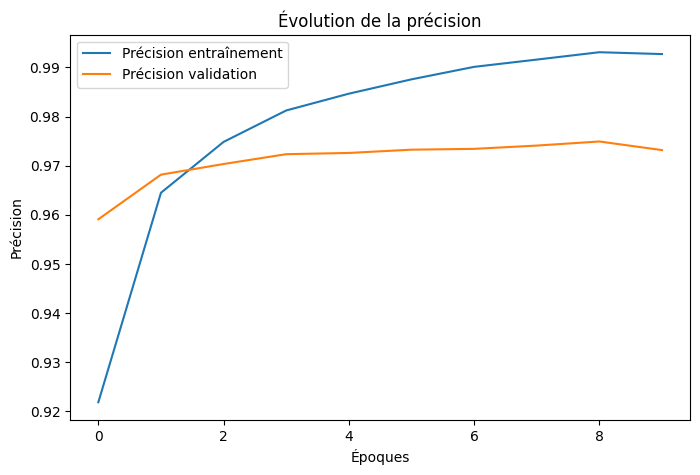

In [9]:


plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Précision entraînement")
plt.plot(history.history["val_accuracy"], label="Précision validation")

plt.title("Évolution de la précision")
plt.xlabel("Époques")
plt.ylabel("Précision")
plt.legend()
plt.show()

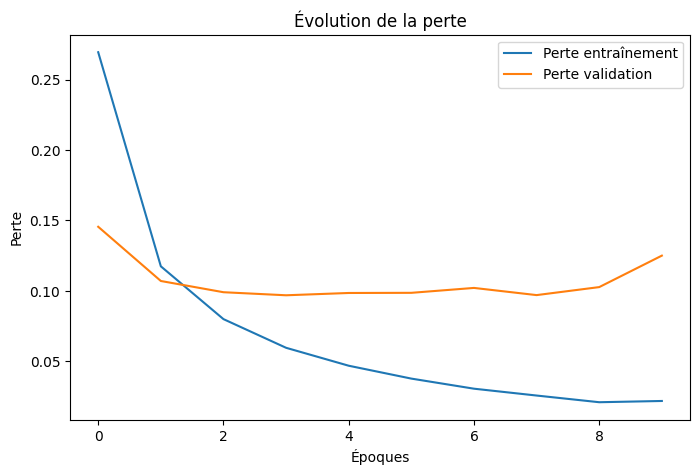

In [10]:


plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Perte entraînement")
plt.plot(history.history["val_loss"], label="Perte validation")

plt.title("Évolution de la perte")
plt.xlabel("Époques")
plt.ylabel("Perte")
plt.legend()
plt.show()

In [11]:


test_loss, test_accuracy = model.evaluate(x_test, y_test_one_hot)

print("Perte sur les données de test :", test_loss)
print("Précision sur les données de test :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9768 - loss: 0.1070
Perte sur les données de test : 0.10703552514314651
Précision sur les données de test : 0.9768000245094299


In [12]:


y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Premières vraies étiquettes :", y_test[:10])
print("Premières prédictions :", y_pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Premières vraies étiquettes : [7 2 1 0 4 1 4 9 5 9]
Premières prédictions : [7 2 1 0 4 1 4 9 5 9]


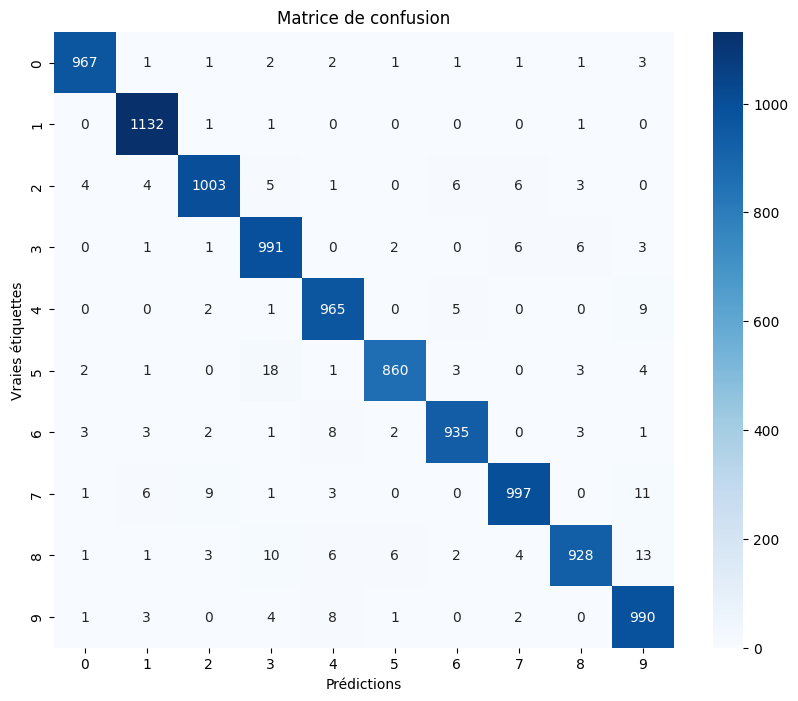

In [13]:


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Vraies étiquettes")
plt.show()

In [14]:


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.96      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.95      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [15]:

errors = y_pred != y_test

wrong_true_labels = y_test[errors]

unique, counts = np.unique(wrong_true_labels, return_counts=True)

error_by_digit = dict(zip(unique, counts))

print("Nombre d'erreurs par chiffre :")
for digit, count in error_by_digit.items():
    print(f"Chiffre {digit} : {count} erreurs")

Nombre d'erreurs par chiffre :
Chiffre 0 : 13 erreurs
Chiffre 1 : 3 erreurs
Chiffre 2 : 29 erreurs
Chiffre 3 : 19 erreurs
Chiffre 4 : 17 erreurs
Chiffre 5 : 32 erreurs
Chiffre 6 : 23 erreurs
Chiffre 7 : 31 erreurs
Chiffre 8 : 46 erreurs
Chiffre 9 : 19 erreurs


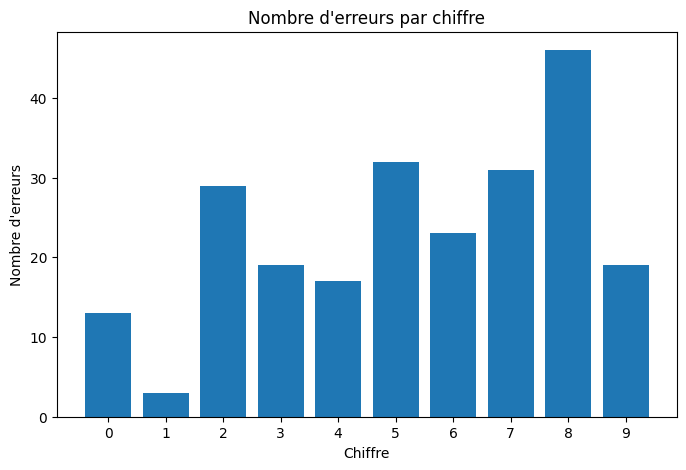

In [16]:


plt.figure(figsize=(8, 5))

plt.bar(error_by_digit.keys(), error_by_digit.values())

plt.title("Nombre d'erreurs par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre d'erreurs")
plt.xticks(range(10))
plt.show()

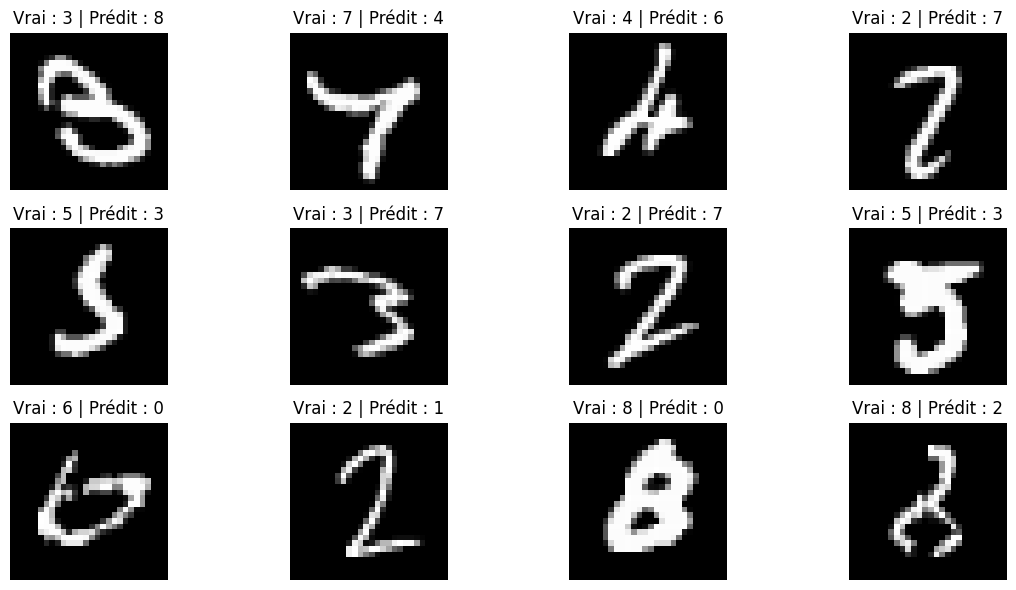

In [17]:


wrong_indices = np.where(errors)[0]

plt.figure(figsize=(12, 6))

for i in range(12):
    index = wrong_indices[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[index], cmap="gray")
    plt.title(f"Vrai : {y_test[index]} | Prédit : {y_pred[index]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:


model_2 = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_2 = model_2.fit(
    x_train,
    y_train_one_hot,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

test_loss_2, test_accuracy_2 = model_2.evaluate(x_test, y_test_one_hot)

print("Précision du premier modèle :", test_accuracy)
print("Précision du deuxième modèle :", test_accuracy_2)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9239 - loss: 0.2561 - val_accuracy: 0.9629 - val_loss: 0.1229
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9703 - loss: 0.0973 - val_accuracy: 0.9731 - val_loss: 0.0927
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9807 - loss: 0.0643 - val_accuracy: 0.9734 - val_loss: 0.0878
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9862 - loss: 0.0450 - val_accuracy: 0.9734 - val_loss: 0.0916
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9895 - loss: 0.0330 - val_accuracy: 0.9742 - val_loss: 0.0954
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9911 - loss: 0.0271 - val_accuracy: 0.9742 - val_loss: 0.0926
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9931 - loss: 0.0213 - val_accuracy: 0.9768 - val_loss: 0.1021
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9928 - loss: 0.0209 - val_accuracy: 0.9725 - val_

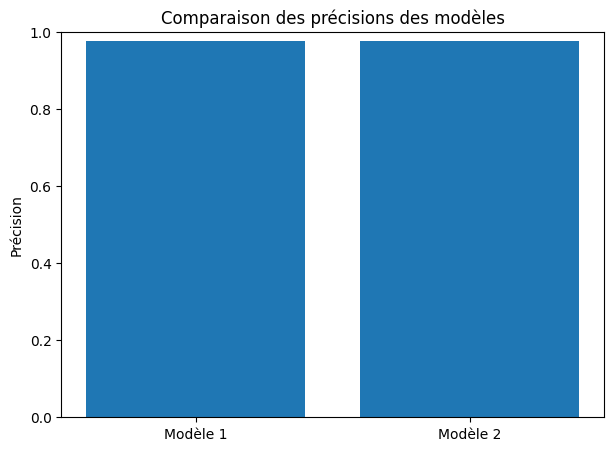

In [19]:


models_names = ["Modèle 1", "Modèle 2"]
accuracies = [test_accuracy, test_accuracy_2]

plt.figure(figsize=(7, 5))

plt.bar(models_names, accuracies)

plt.title("Comparaison des précisions des modèles")
plt.ylabel("Précision")
plt.ylim(0, 1)
plt.show()

Dans cet exercice, nous avons construit un réseau neuronal entièrement connecté pour reconnaître les chiffres manuscrits du dataset MNIST.

Nous avons d'abord chargé les images, normalisé les valeurs des pixels entre 0 et 1, puis converti les étiquettes en format one-hot. Ensuite, nous avons créé un modèle séquentiel avec une couche Flatten, deux couches cachées utilisant la fonction d’activation ReLU et une couche de sortie Softmax pour classifier les chiffres de 0 à 9.

Le modèle a été entraîné pendant 10 époques avec un ensemble de validation afin de suivre l’évolution de la précision et de la perte. Après l'entraînement, nous avons évalué le modèle sur les données de test et affiché une matrice de confusion pour analyser les erreurs.

La matrice de confusion permet d’identifier les chiffres que le modèle confond le plus souvent. Enfin, une petite expérience de réglage d’hyperparamètres a été réalisée en modifiant le nombre de neurones et la taille du batch afin d’observer l’impact sur les performances.